In [99]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

#Read data
pd.set_option('display.max_columns', None)
data = pd.read_csv('globalterrorismdb_0221dist.csv', skiprows=[1], skipinitialspace=True)


#Subset my interested columns
df = data[['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'country_txt', 'region_txt', 'crit1', 'crit2', 'crit3', 'attacktype1_txt', 
           'attacktype2_txt', 'attacktype3_txt', 'targtype1_txt', 'targtype2_txt', 'targtype3_txt', 'gname', 'claimed',
           'weaptype1_txt', 'weaptype2_txt', 'weaptype3_txt', 'nkill','individual','success', 'ishostkid', 'property',
           'nwound', 'extended', 'resolution','INT_LOG', 'INT_IDEO', 'INT_MISC', 'INT_ANY']]

df_post2012 = df[df['iyear'] >= 2012]

# 18% unknown (-9)
df['property']  = df['property'].replace(-9, np.nan).fillna(0).astype(int)

# 0.44% unknown - can drop
df['ishostkid'] = df['ishostkid'].replace(-9, np.nan)
df = df.dropna(subset=['ishostkid'])
df['ishostkid'] = df['ishostkid'].astype(int)

# About 10% null, since target value we should drop to preserve data integrity
df = df.dropna(subset=['nkill', 'nwound'])

#Make a log transformed column for these values to deal with high variance data
df_post2012['log_nkill'] = np.log1p(df_post2012['nkill'])
df_post2012['log_nwound'] = np.log1p(df_post2012['nwound'])

df_post2012['violence_level'] = (
    2 * df_post2012['nkill'].fillna(0) + df_post2012['nwound'].fillna(0)
).where(
    df_post2012['nkill'].notna() | df_post2012['nwound'].notna()
)




print((df_post2012['nkill'] == 0).mean())
print((df_post2012['nwound'] == 0).mean())
print((df_post2012['violence_level'] == 0).mean())

pred_cols = [
    'country_txt', 'region_txt',
    'attacktype1_txt',
    'targtype1_txt',
    'weaptype1_txt',
    'individual', 'nperps',
    'success', 'extended', 'claimed',
    'ishostkid', 'property',
    'INT_ANY',
]

resp_cols = [
    'nkill', 'nwound'
]



df2 = data[pred_cols].copy()
df3 = data[resp_cols].copy()

#For right now I'm going to replace with nan
df2 = df2.replace(-9, np.nan)
df2 = df2.replace(-99, np.nan)
df2 = df2.replace("Unknown", np.nan)

#For right now I'm going to replace with nan
df3 = df3.replace(-9, np.nan)
df3 = df3.replace(-99, np.nan)
df3 = df3.replace("Unknown", np.nan)


print(df2.info())
print(df2.describe())

print(df3.info())
print(df3.describe())
#about 44.0% of attacks have no deaths. about 49.6% of all attacks have no wounded, and about 30% of attacks have a violence level of 0 (no kills or wounded)

C:\Users\alist\AppData\Local\Temp\ipykernel_48172\2174260663.py:10: DtypeWarning: Columns (4,31,33,54,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('globalterrorismdb_0221dist.csv', skiprows=[1], skipinitialspace=True)
C:\Users\alist\AppData\Local\Temp\ipykernel_48172\2174260663.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['property']  = df['property'].replace(-9, np.nan).fillna(0).astype(int)
C:\Users\alist\AppData\Local\Temp\ipykernel_48172\2174260663.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

0.44031453260993597
0.49606315549239083
0.2997811135201303
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201182 entries, 0 to 201181
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   country_txt      201182 non-null  object 
 1   region_txt       201182 non-null  object 
 2   attacktype1_txt  191592 non-null  object 
 3   targtype1_txt    194367 non-null  object 
 4   weaptype1_txt    182721 non-null  object 
 5   individual       201182 non-null  int64  
 6   nperps           31537 non-null   float64
 7   success          201182 non-null  int64  
 8   extended         201182 non-null  int64  
 9   claimed          133616 non-null  float64
 10  ishostkid        200511 non-null  float64
 11  property         174644 non-null  float64
 12  INT_ANY          109881 non-null  float64
dtypes: float64(5), int64(3), object(5)
memory usage: 20.0+ MB
None
          individual        nperps        success       e

## Examine Distribution of Violence Level

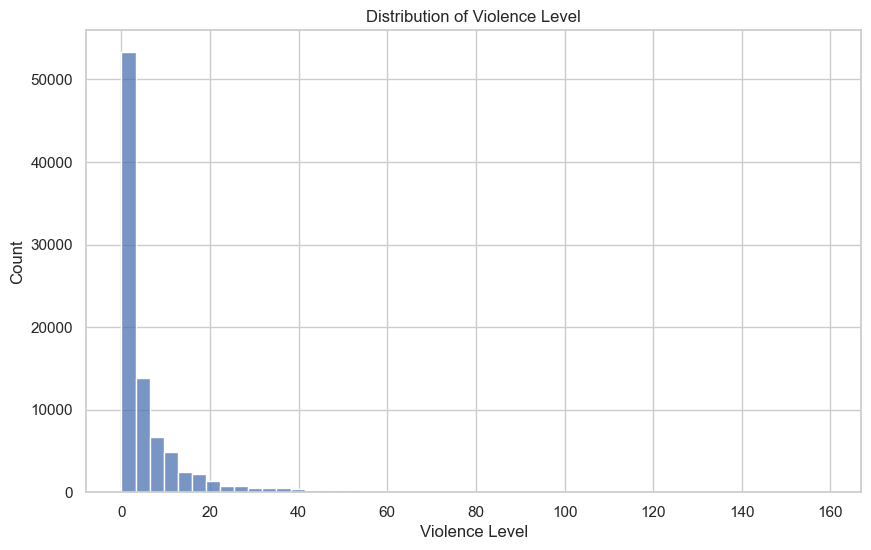

In [101]:
#Build distribution plot for Violence Level
plt.figure(figsize=(10,6))
sns.histplot(df_trimmed['violence_level'], bins=50)
plt.title('Distribution of Violence Level')
plt.xlabel('Violence Level')
plt.ylabel('Count')
plt.show()

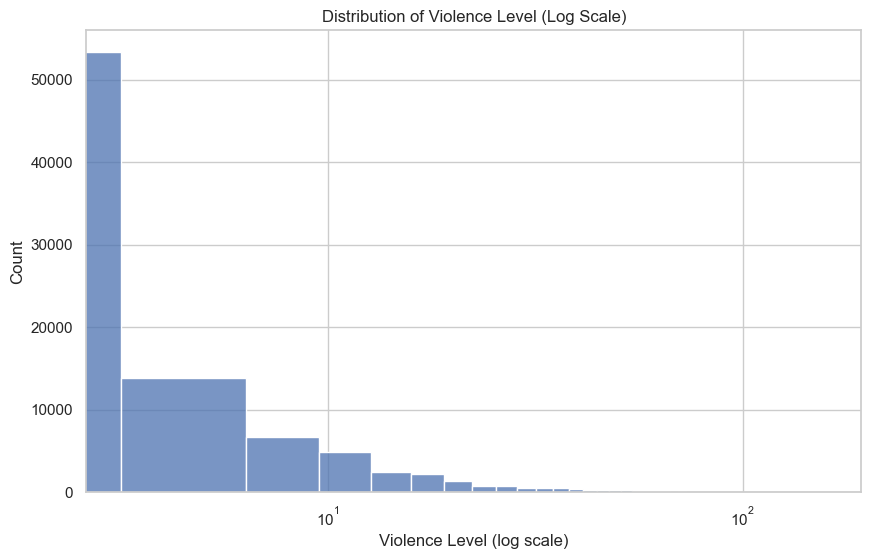

In [104]:
#Build distribution plot for log transformed Violence Level
plt.figure(figsize=(10,6))
sns.histplot(df_trimmed['violence_level'], bins=50)
plt.xscale('log')
plt.title('Distribution of Violence Level (Log Scale)')
plt.xlabel('Violence Level (log scale)')
plt.ylabel('Count')
plt.show()

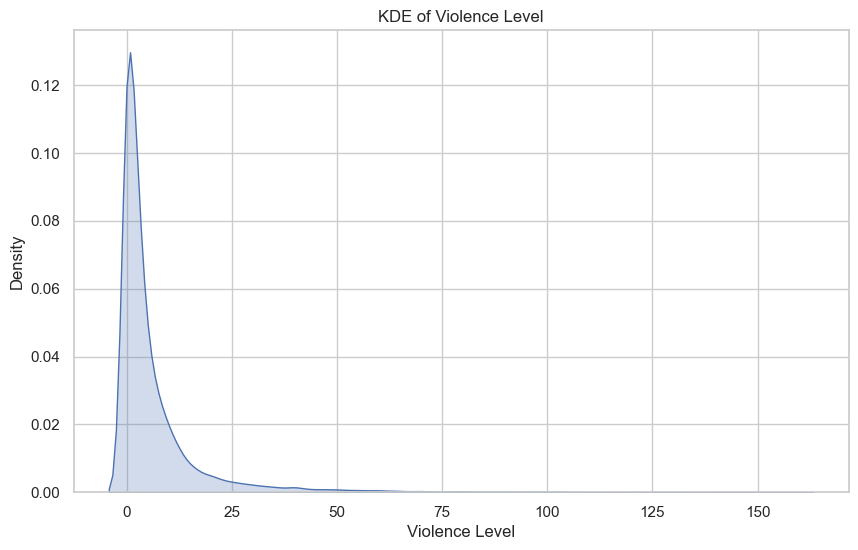

In [106]:
#Build smoothed distribution plot for Violence Level
plt.figure(figsize=(10,6))
sns.kdeplot(df_trimmed['violence_level'], fill=True)
plt.title('KDE of Violence Level')
plt.xlabel('Violence Level')
plt.show()

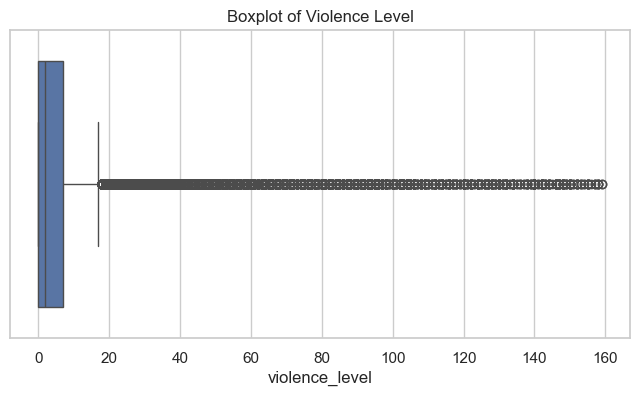

In [107]:
#Build Boxplot of Violence level
plt.figure(figsize=(8,4))
sns.boxplot(x=df_trimmed['violence_level'])
plt.title('Boxplot of Violence Level')
plt.show()

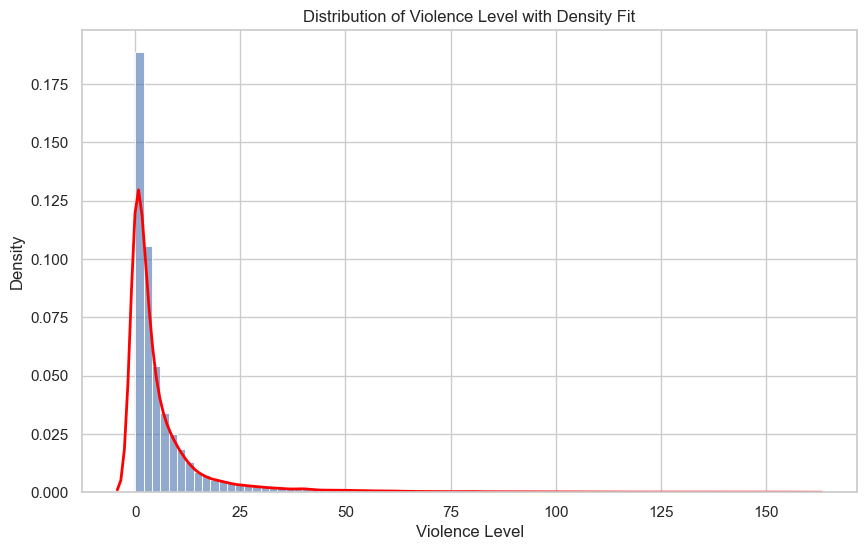

In [109]:
#Grab distribution plot with density fit for presentation
plt.figure(figsize=(10,6))
sns.histplot(df_trimmed['violence_level'], bins=80, stat='density', alpha=0.6)
sns.kdeplot(df_trimmed['violence_level'], color='red', linewidth=2)

plt.title('Distribution of Violence Level with Density Fit')
plt.xlabel('Violence Level')
plt.ylabel('Density')
plt.show()

## Time Series of attacks

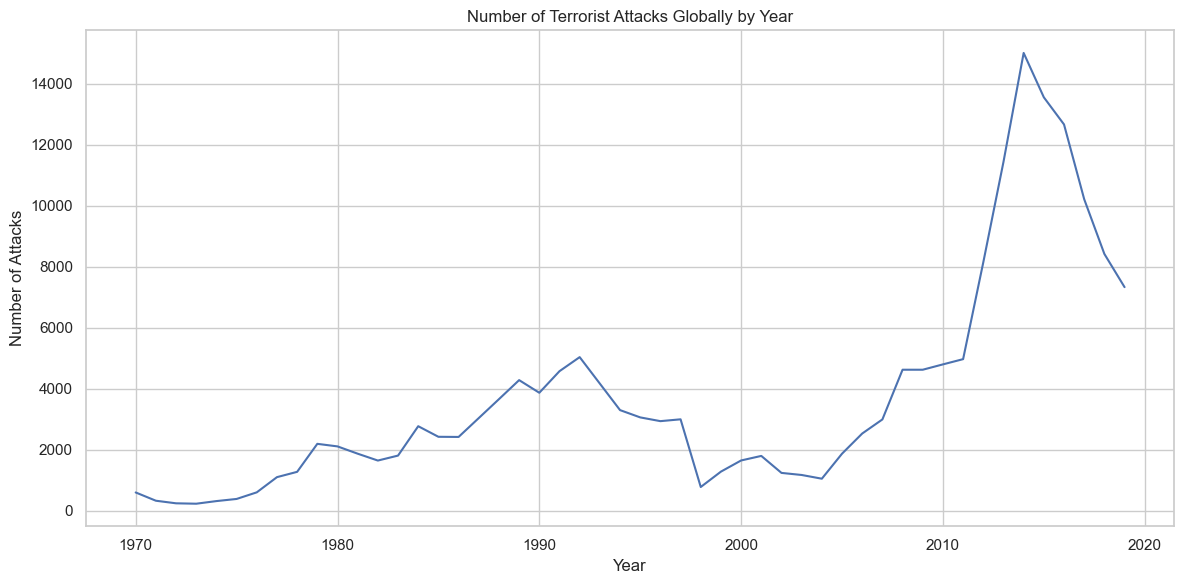

In [112]:
#Time series of attacks per year
attacks_per_year = (
    df.groupby("iyear")
      .size()
      .reset_index(name="attack_count")
)

plt.figure(figsize=(12, 6))

plt.plot(
    attacks_per_year["iyear"],
    attacks_per_year["attack_count"]
)

plt.title("Number of Terrorist Attacks Globally by Year")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")

plt.grid(True)
plt.tight_layout()

plt.show()

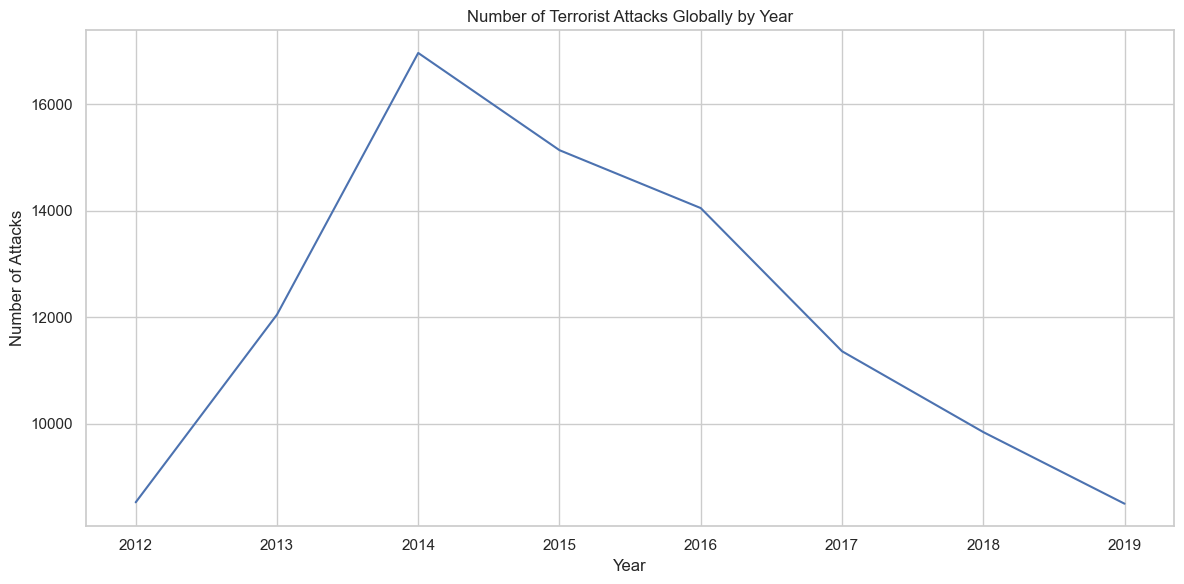

In [113]:
#Closer look at the range we focused on
attacks_per_year = (
    df_post2012.groupby("iyear")
      .size()
      .reset_index(name="attack_count")
)

plt.figure(figsize=(12, 6))

plt.plot(
    attacks_per_year["iyear"],
    attacks_per_year["attack_count"]
)

plt.title("Number of Terrorist Attacks Globally by Year")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")

plt.grid(True)
plt.tight_layout()

plt.show()

## Heatmaps for Region data

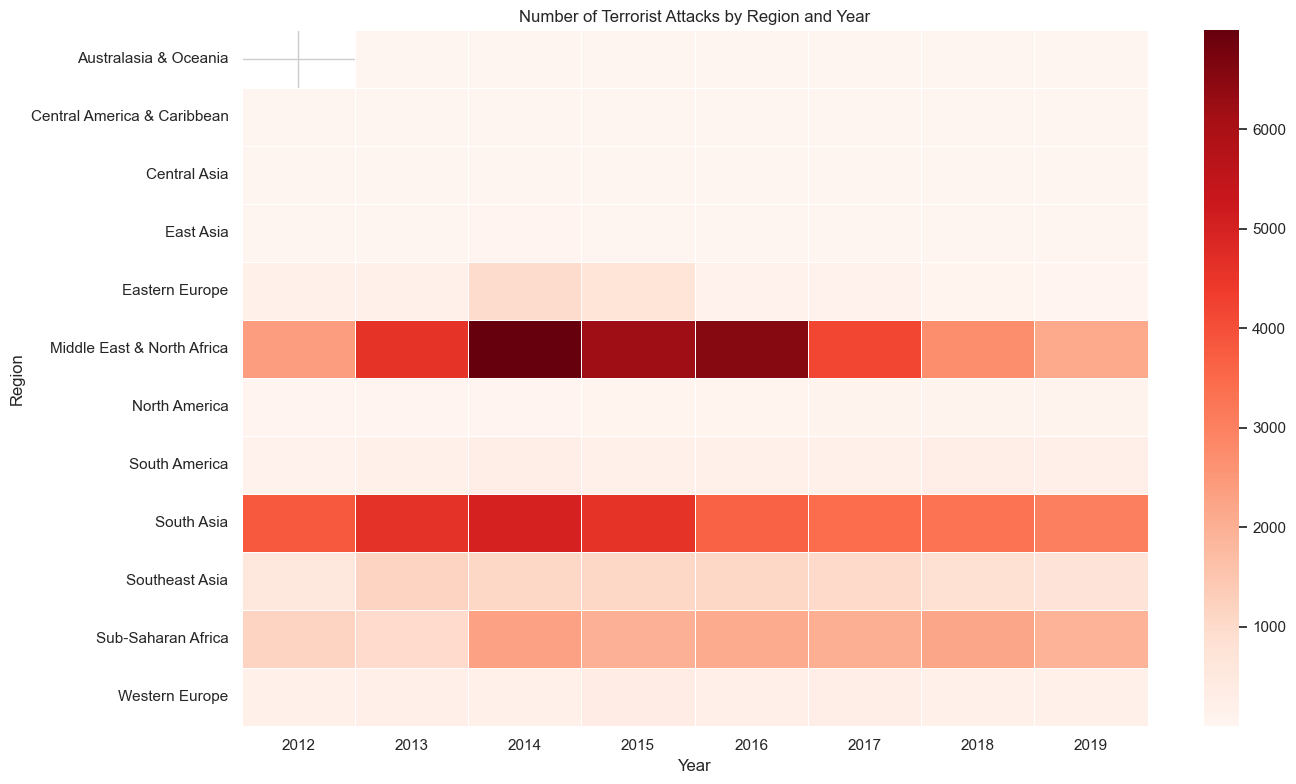

In [117]:
#Build a heatmap for number of attacks by region
attacks = (df_post2012.groupby(['region_txt', 'iyear']).size().reset_index(name="attack_count"))

heatmap_data = attacks.pivot(
    index="region_txt",
    columns="iyear",
    values="attack_count"
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    cmap="Reds",
    linewidths=0.5
)

plt.title("Number of Terrorist Attacks by Region and Year")
plt.xlabel("Year")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

<Axes: xlabel='iyear', ylabel='region_txt'>

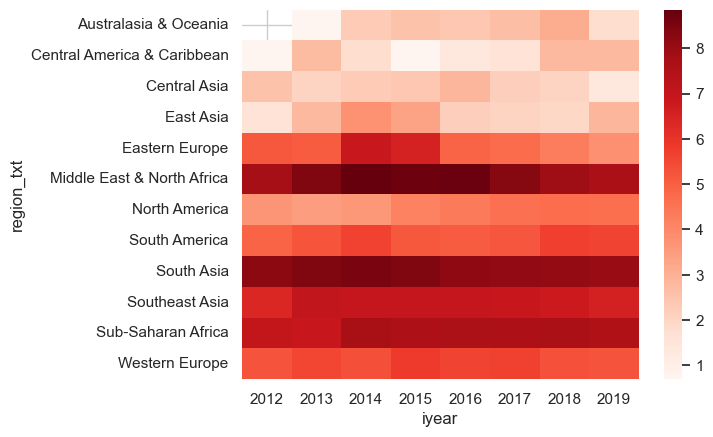

In [119]:
#Because the number of attacks in the middle east and north africa (Specically from 2013-2017)
#cause heavy bias in the graph I tried a log scaled graph so that comparing the other regions/times was easier.
sns.heatmap(
    np.log1p(heatmap_data),
    cmap="Reds"
)

## Scatterplots for nkill vs nwound

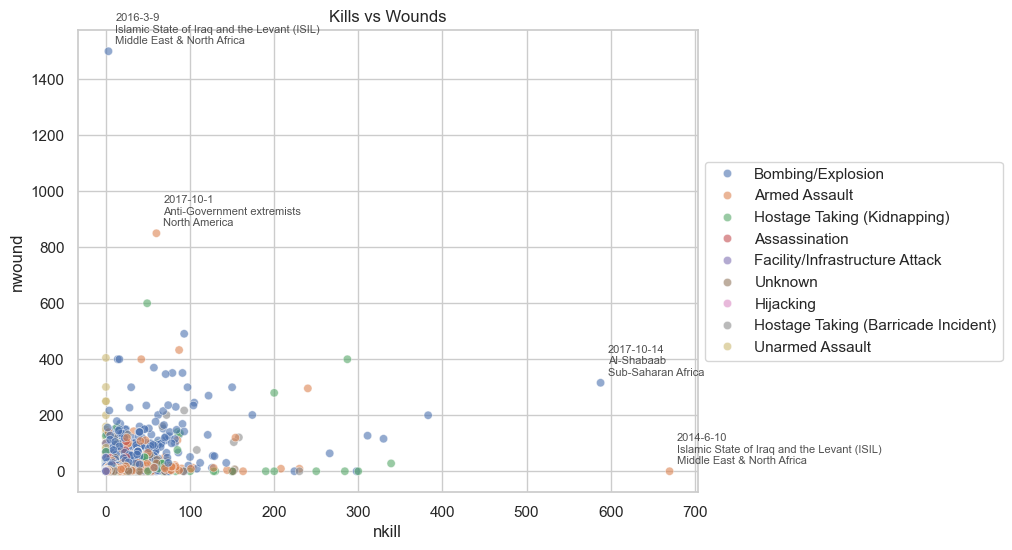

In [122]:
#Plot a scatterplot of nkill vs nwound
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_post2012,
    x='nkill',
    y='nwound',
    hue='attacktype1_txt',
    alpha=0.6
)
plt.title("Kills vs Wounds")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))


#Find and label the most extreme outliers
outliers = df_post2012[
    (df_post2012['nkill'] > 400) | 
    (df_post2012['nwound'] > 600)
]

for _, row in outliers.iterrows():
    label = f"{int(row['iyear'])}-{int(row['imonth'])}-{int(row['iday'])}\n{row['gname']}\n{row['region_txt']}"
    
    plt.annotate(
        label,
        (row['nkill'], row['nwound']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        alpha=0.8
    )

plt.show()

#2017-10-1 --- Las Vegas Shooting
#2014-6-10 --- Execution of 600+ prisoners by ISIL (ISIS) (Badush Prison Massacre)
#2016-3-9 --- Chemical weapon attack on Iraqi town of Taza
#2017-10-14 --- Bombing in Somalia


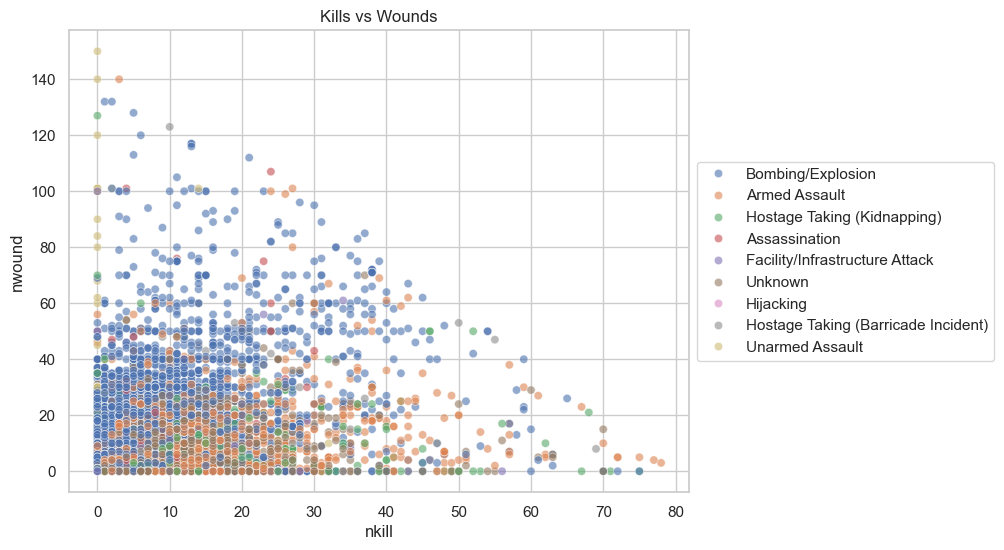

In [124]:
#Cut out the top .03% of events by violence level to clean up severe outliers.
p = 0.997
threshold = df_post2012['violence_level'].quantile(p)
df_trimmed = df_post2012[df_post2012['violence_level'] <= threshold]

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_trimmed,
    x='nkill',
    y='nwound',
    hue='attacktype1_txt',
    alpha=0.6
)
plt.title("Kills vs Wounds")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))


plt.show()

## Comparing Mean and Median for important statistics

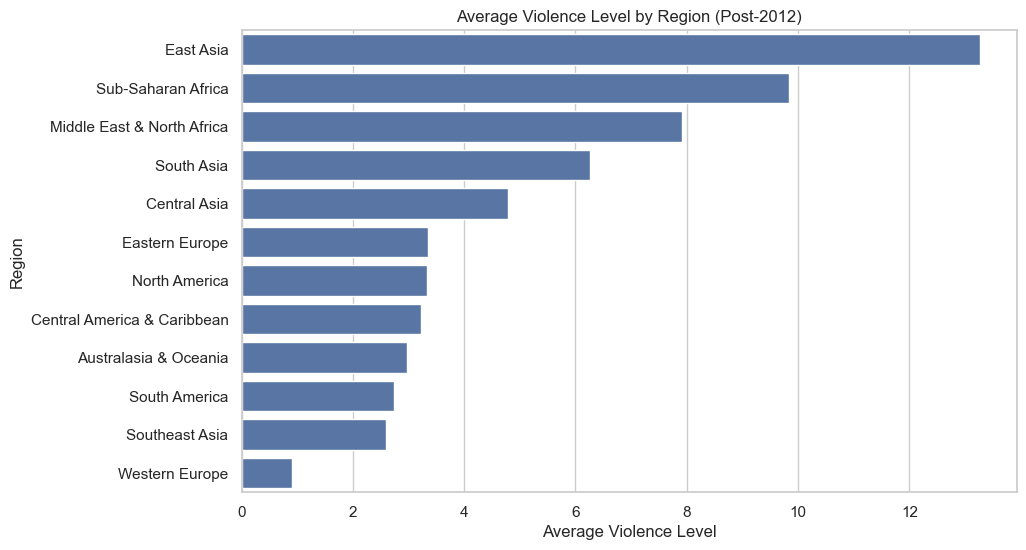

In [126]:
#Make histogram of mean violence by region
region_avg = (
    df_trimmed
    .groupby('region_txt')['violence_level']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_avg.values,
    y=region_avg.index
)

plt.xlabel("Average Violence Level")
plt.ylabel("Region")
plt.title("Average Violence Level by Region (Post-2012)")

plt.show()

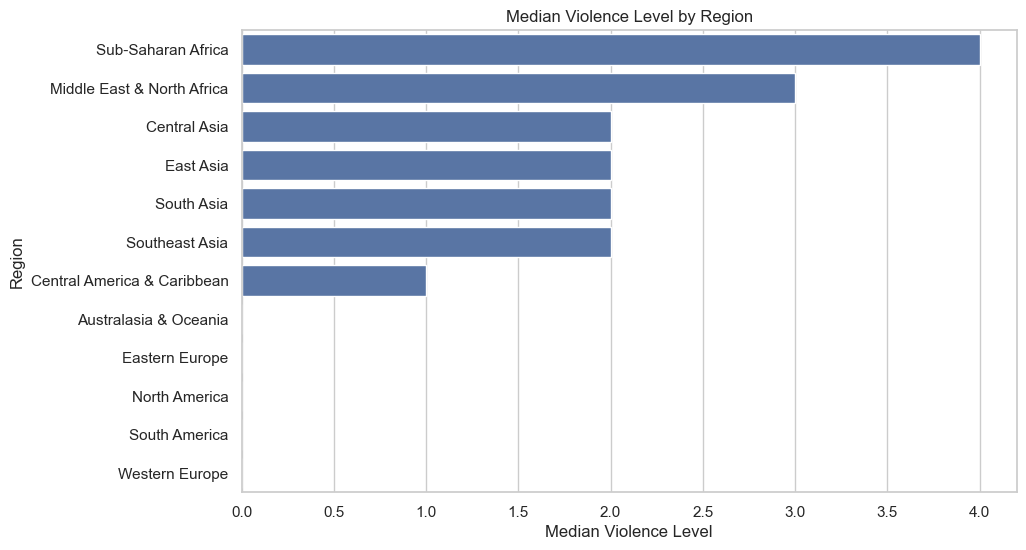

In [127]:
#Make histogram of median violence by region
region_avg = (
    df_trimmed
    .groupby('region_txt')['violence_level']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_avg.values,
    y=region_avg.index
)

plt.xlabel("Median Violence Level")
plt.ylabel("Region")
plt.title("Median Violence Level by Region")

plt.show()

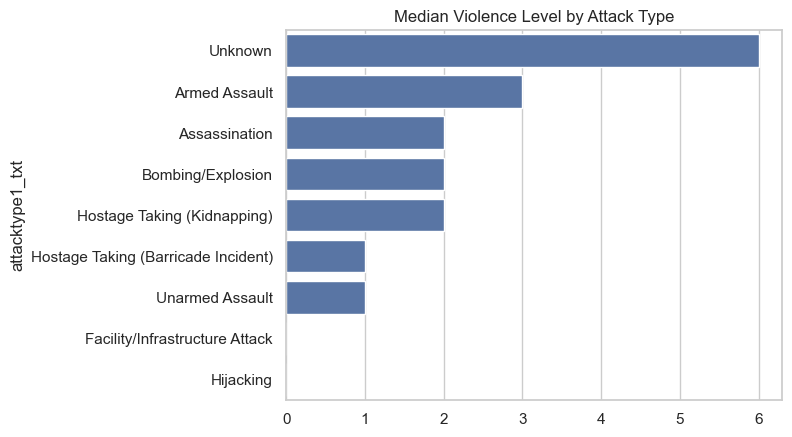

In [128]:
#Make histogram of median violence by Attack Type
attack_avg = (
    df_trimmed
    .groupby('attacktype1_txt')['violence_level']
    .median()
    .sort_values(ascending=False)
)

top_attack_avg = attack_avg.head(10)

sns.barplot(x=top_attack_avg.values, y=top_attack_avg.index)
plt.title("Median Violence Level by Attack Type")
plt.show()


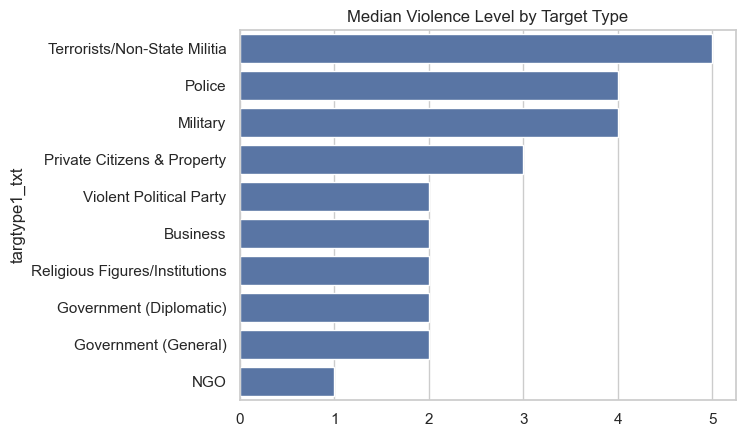

In [129]:
#Make histogram of median violence by Target Type
target_avg = (
    df_trimmed
    .groupby('targtype1_txt')['violence_level']
    .median()
    .sort_values(ascending=False)
)

top_target_avg = target_avg.head(10)

sns.barplot(x=top_target_avg.values, y=top_target_avg.index)
plt.title("Median Violence Level by Target Type")
plt.show()

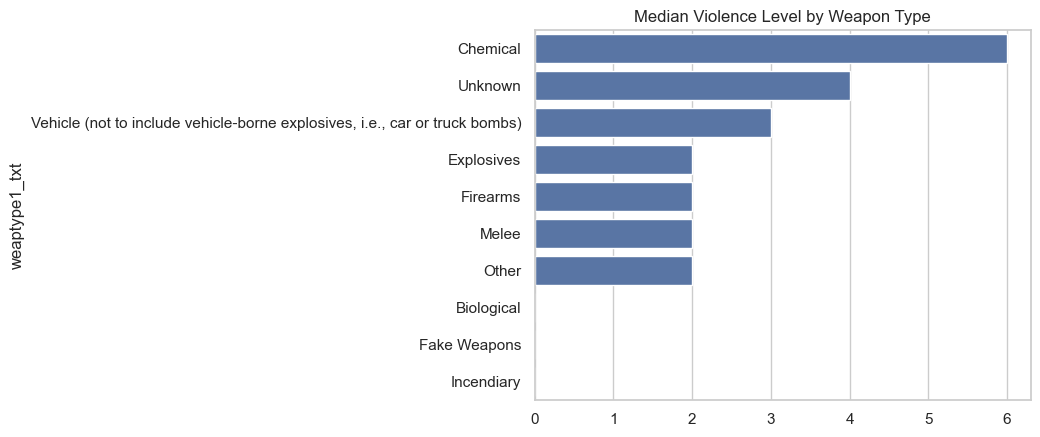

In [131]:
#Make histogram of median violence by Weapon Type
weapon_avg = (
    df_trimmed
    .groupby('weaptype1_txt')['violence_level']
    .median()
    .sort_values(ascending=False)
)

top_weapon_avg = weapon_avg.head(10)

sns.barplot(x=top_weapon_avg.values, y=top_weapon_avg.index)
plt.title("Median Violence Level by Weapon Type")
plt.show()

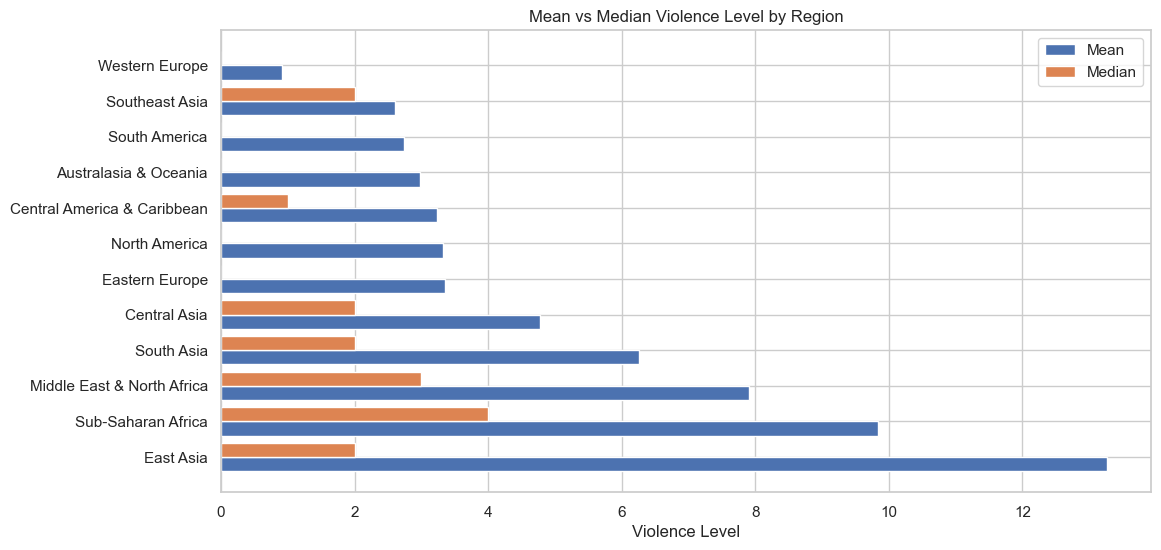

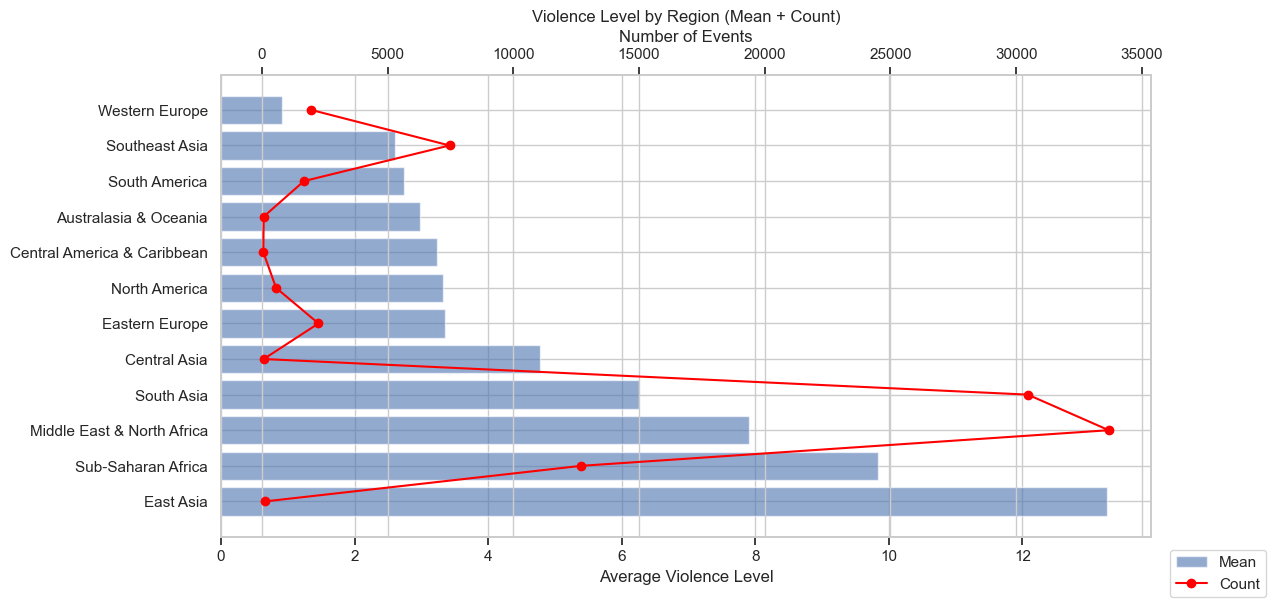

In [132]:
#Building a more complex plot to compare median and mode, and show the relationship between mean and number of attacks. (region)
region_stats = (
    df_trimmed
    .groupby('region_txt')['violence_level']
    .agg(['mean', 'median', 'count'])
)

region_stats = region_stats[region_stats['count'] > 50]

region_stats = region_stats.sort_values('mean', ascending=False)

x = np.arange(len(region_stats))
width = 0.4

plt.figure(figsize=(12, 6))

plt.barh(x - width/2, region_stats['mean'], height=width, label='Mean')
plt.barh(x + width/2, region_stats['median'], height=width, label='Median')

plt.yticks(x, region_stats.index)
plt.xlabel("Violence Level")
plt.title("Mean vs Median Violence Level by Region")

plt.legend()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Mean bars
ax1.barh(region_stats.index, region_stats['mean'], alpha=0.6, label='Mean')
ax1.set_xlabel("Average Violence Level")

# Second axis for counts
ax2 = ax1.twiny()
ax2.plot(region_stats['count'], region_stats.index, 'o-', color='red', label='Count')
ax2.set_xlabel("Number of Events")

plt.title("Violence Level by Region (Mean + Count)")

fig.legend(loc='lower right')
plt.show()

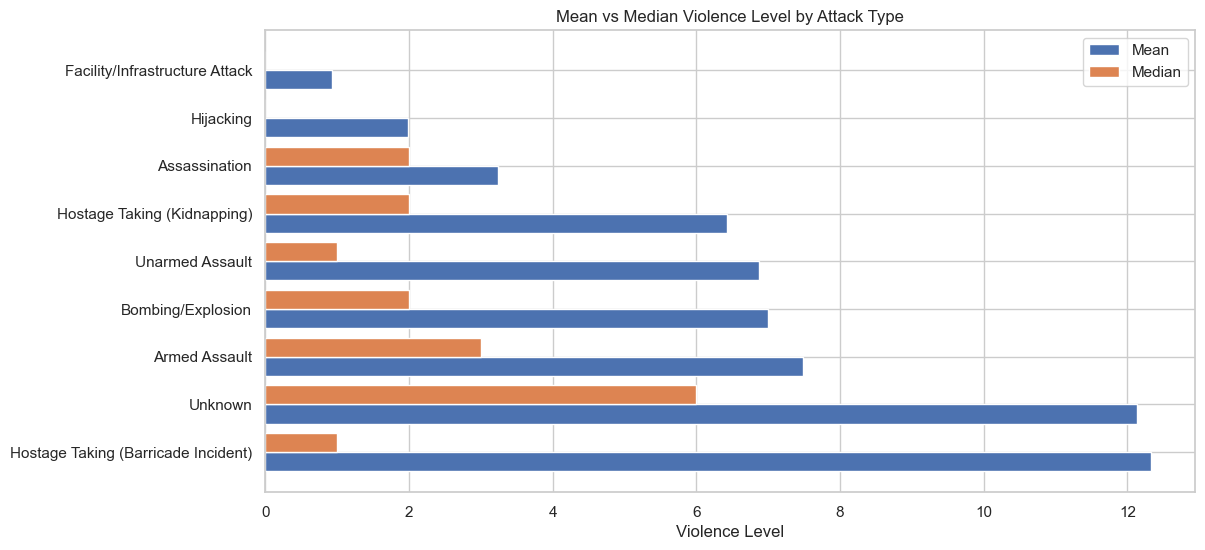

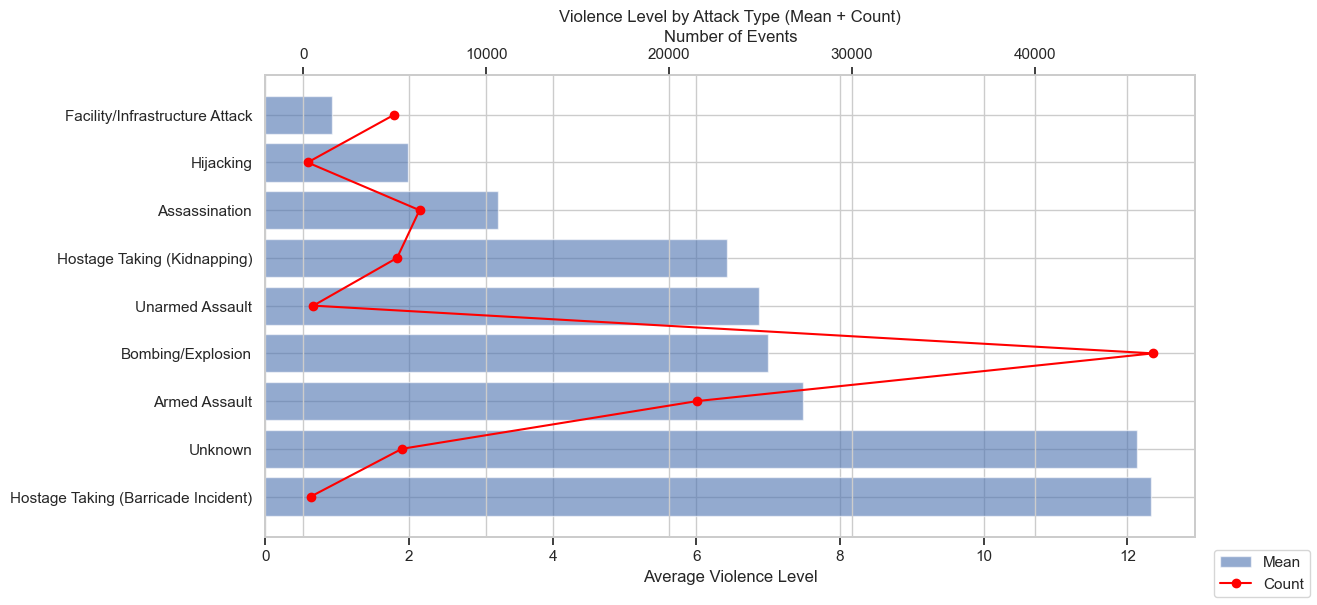

In [133]:
#Building a more complex plot to compare median and mode, and show the relationship between mean and number of attacks. (Attack Type)
attack_stats = (
    df_trimmed
    .groupby('attacktype1_txt')['violence_level']
    .agg(['mean', 'median', 'count'])
)

attack_stats = attack_stats[attack_stats['count'] > 50]

attack_stats = attack_stats.sort_values('mean', ascending=False)

x = np.arange(len(attack_stats))
width = 0.4

plt.figure(figsize=(12, 6))

plt.barh(x - width/2, attack_stats['mean'], height=width, label='Mean')
plt.barh(x + width/2, attack_stats['median'], height=width, label='Median')

plt.yticks(x, attack_stats.index)
plt.xlabel("Violence Level")
plt.title("Mean vs Median Violence Level by Attack Type")

plt.legend()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Mean bars
ax1.barh(attack_stats.index, attack_stats['mean'], alpha=0.6, label='Mean')
ax1.set_xlabel("Average Violence Level")

# Second axis for counts
ax2 = ax1.twiny()
ax2.plot(attack_stats['count'], attack_stats.index, 'o-', color='red', label='Count')
ax2.set_xlabel("Number of Events")

plt.title("Violence Level by Attack Type (Mean + Count)")

fig.legend(loc='lower right')
plt.show()

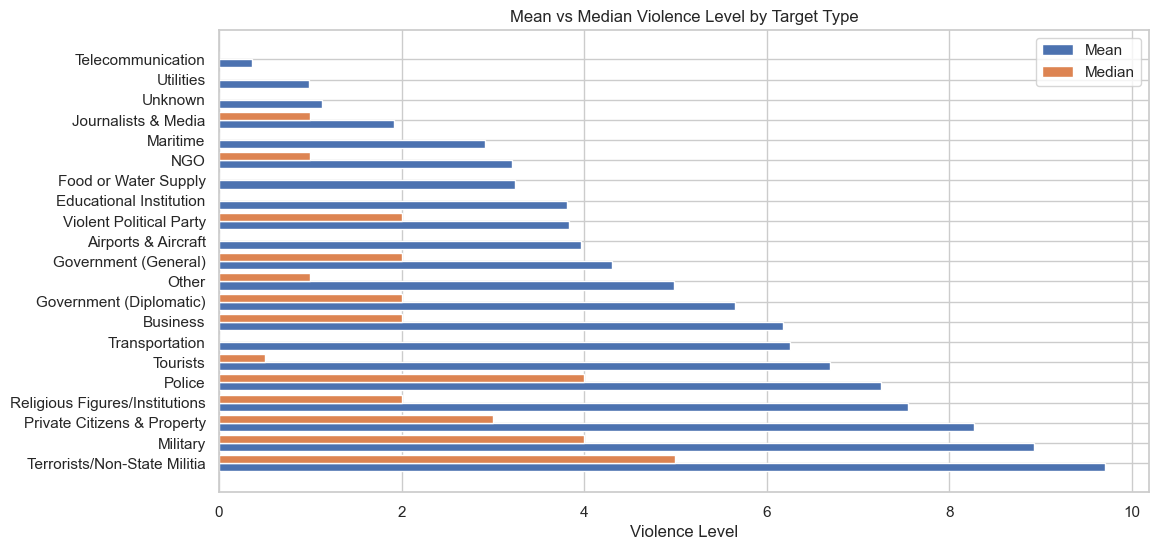

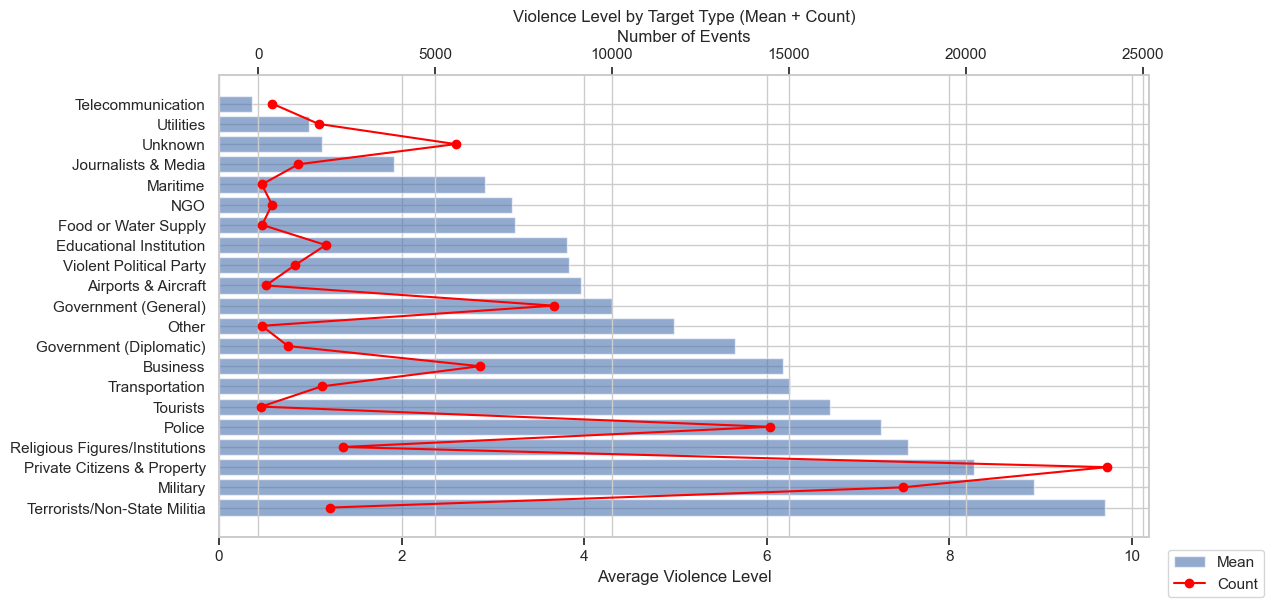

In [134]:
#Building a more complex plot to compare median and mode, and show the relationship between mean and number of attacks. (Target Type)
target_stats = (
    df_trimmed
    .groupby('targtype1_txt')['violence_level']
    .agg(['mean', 'median', 'count'])
)

target_stats = target_stats[target_stats['count'] > 50]

target_stats = target_stats.sort_values('mean', ascending=False)

x = np.arange(len(target_stats))
width = 0.4

plt.figure(figsize=(12, 6))

plt.barh(x - width/2, target_stats['mean'], height=width, label='Mean')
plt.barh(x + width/2, target_stats['median'], height=width, label='Median')

plt.yticks(x, target_stats.index)
plt.xlabel("Violence Level")
plt.title("Mean vs Median Violence Level by Target Type")

plt.legend()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Mean bars
ax1.barh(target_stats.index, target_stats['mean'], alpha=0.6, label='Mean')
ax1.set_xlabel("Average Violence Level")

# Second axis for counts
ax2 = ax1.twiny()
ax2.plot(target_stats['count'], target_stats.index, 'o-', color='red', label='Count')
ax2.set_xlabel("Number of Events")

plt.title("Violence Level by Target Type (Mean + Count)")

fig.legend(loc='lower right')
plt.show()

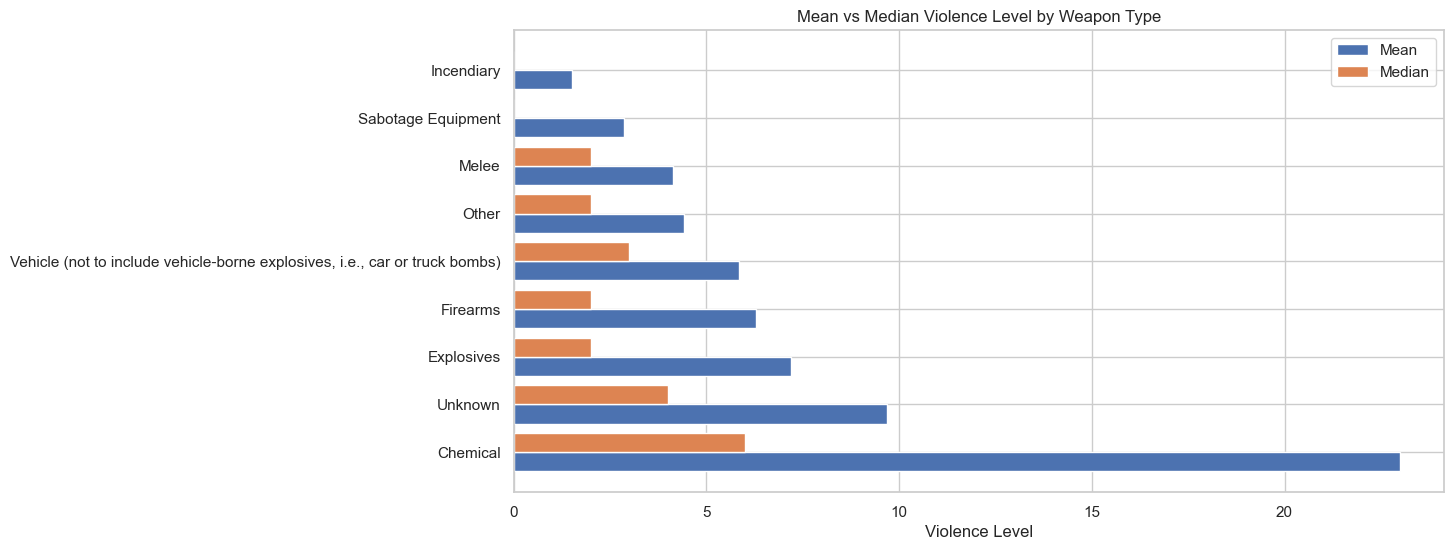

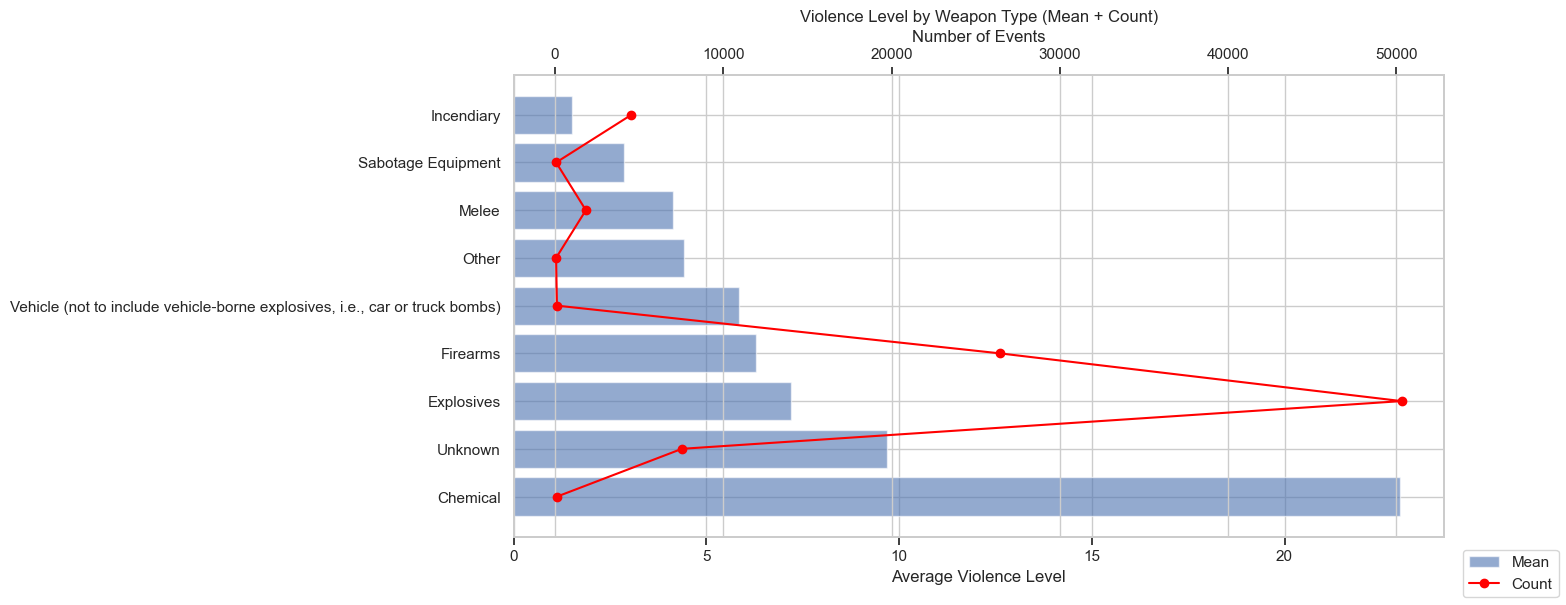

In [135]:
#Building a more complex plot to compare median and mode, and show the relationship between mean and number of attacks. (Weapon Type)
weapon_stats = (
    df_trimmed
    .groupby('weaptype1_txt')['violence_level']
    .agg(['mean', 'median', 'count'])
)

weapon_stats = weapon_stats[weapon_stats['count'] > 50]

weapon_stats = weapon_stats.sort_values('mean', ascending=False)

x = np.arange(len(weapon_stats))
width = 0.4

plt.figure(figsize=(12, 6))

plt.barh(x - width/2, weapon_stats['mean'], height=width, label='Mean')
plt.barh(x + width/2, weapon_stats['median'], height=width, label='Median')

plt.yticks(x, weapon_stats.index)
plt.xlabel("Violence Level")
plt.title("Mean vs Median Violence Level by Weapon Type")

plt.legend()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Mean bars
ax1.barh(weapon_stats.index, weapon_stats['mean'], alpha=0.6, label='Mean')
ax1.set_xlabel("Average Violence Level")

# Second axis for counts
ax2 = ax1.twiny()
ax2.plot(weapon_stats['count'], weapon_stats.index, 'o-', color='red', label='Count')
ax2.set_xlabel("Number of Events")

plt.title("Violence Level by Weapon Type (Mean + Count)")

fig.legend(loc='lower right')
plt.show()

## Quick look at most active/most violent groups

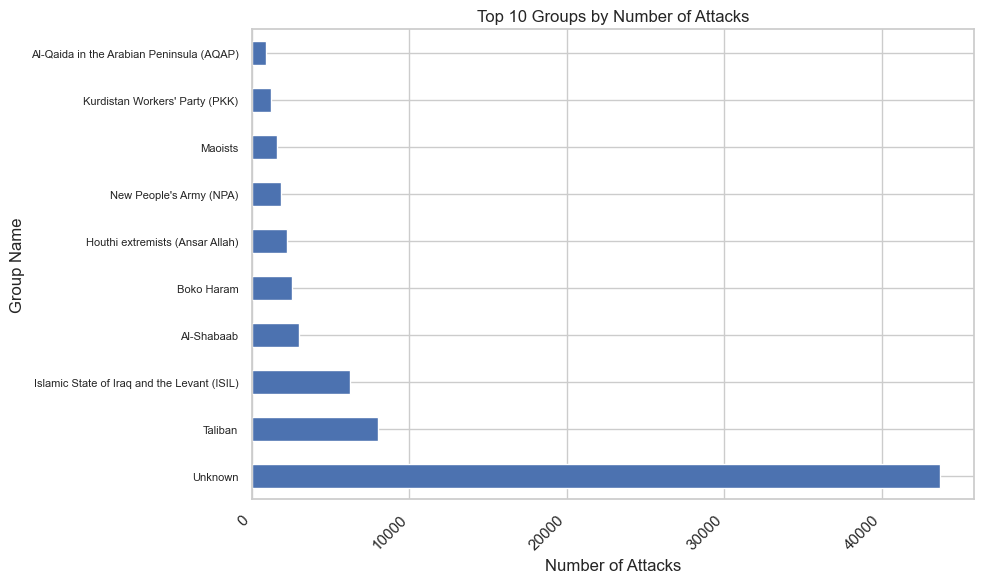

In [140]:
#Make a histogram of the top ten groups by number of attacks
top10_counts = df_trimmed['gname'].value_counts().head(10)
top10_groups = df_trimmed['gname'].value_counts().head(10).index
df_top10 = df_trimmed[df_trimmed['gname'].isin(top10_groups)]

plt.figure(figsize=(10,6))

top10_counts.plot(kind='barh')

plt.xlabel("Number of Attacks")
plt.ylabel("Group Name")
plt.title("Top 10 Groups by Number of Attacks")

plt.xticks(rotation=45, ha='right')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

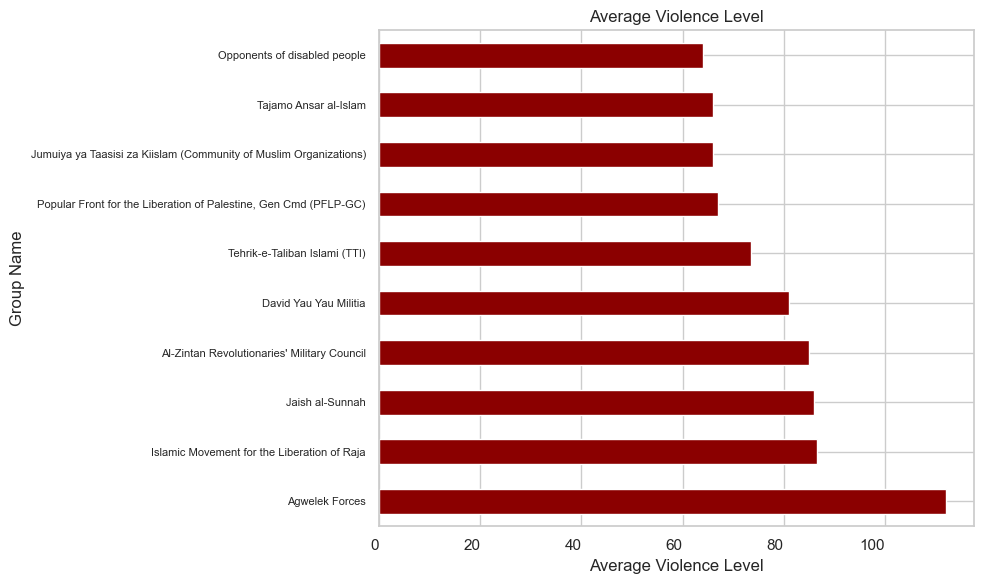

In [142]:
#Make a histogram of the top ten groups by average violence level
top10_violence = (
    df_trimmed
    .groupby('gname')['violence_level']
    .median()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top10_violence.plot(kind='barh', color='darkred')

plt.xlabel("Average Violence Level")
plt.ylabel("Group Name")
plt.title("Average Violence Level")

plt.xticks(rotation=0, ha='right')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## Grab Summary Statistics

In [152]:
#Pull summary statistics for numerical columns
cols = df_post2012.select_dtypes(include='object').columns
df_post2012[cols] = df[cols].astype('category')

#Our final columns used in models.
final_cols = df_post2012[['country_txt', 'region_txt', 'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt',
    'individual','success', 'extended', 'claimed','ishostkid','property','nkill', 'nwound', 'violence_level']]

num_cols = final_cols.select_dtypes(include='number').columns
final_cols[num_cols].describe().round(4)

,individual,success,extended,claimed,ishostkid,property,nkill,nwound,violence_level
count,96397.0000,96397.0000,96397.0000,96397.0000,96397.0000,96397.0000,90978.0000,87383.0000,91357.0000
mean,0.0048,0.8490,0.0677,0.1897,0.0468,-1.3087,2.4955,2.9056,7.7496
std,0.0694,0.3581,0.2513,0.3921,0.6644,3.6870,10.9539,11.6297,27.0816
min,0.0000,0.0000,0.0000,0.0000,-9.0000,-9.0000,0.0000,0.0000,0.0000
25%,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,2.0000
75%,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,2.0000,3.0000,7.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1570.0000,1500.0000,3140.0000


In [154]:
#Pull summary statistics for categorical columns. I tried to make this a bit prettier, but couldn't find a way in notebook
def cat_summary_styled(df, col):
    vc = df[col].value_counts()
    
    summary = pd.DataFrame({
        "Count": vc,
        "Percent (%)": (vc / vc.sum() * 100)
    }).round(2)
    
    return summary.style.format({
        "Count": "{:,}",
        "Percent (%)": "{:.2f}%"
    })


cat_cols = final_cols.select_dtypes(include='category').columns
for col in cat_cols:
    display(cat_summary_styled(df, col))
    print("\n\n")

,Count,Percent (%)
country_txt,,
Iraq,"25,278",13.96%
Afghanistan,"15,071",8.32%
Pakistan,"14,676",8.10%
India,"12,947",7.15%
Colombia,"8,105",4.47%
Philippines,"7,593",4.19%
Peru,"5,396",2.98%
Yemen,"4,498",2.48%
Turkey,"4,299",2.37%


,Count,Percent (%)
region_txt,,
Middle East & North Africa,"51,713",28.55%
South Asia,"48,743",26.91%
South America,"17,624",9.73%
Sub-Saharan Africa,"17,193",9.49%
Western Europe,"14,458",7.98%
Southeast Asia,"13,476",7.44%
Central America & Caribbean,"7,867",4.34%
Eastern Europe,"4,991",2.76%
North America,"3,421",1.89%


,Count,Percent (%)
attacktype1_txt,,
Bombing/Explosion,"89,124",49.21%
Armed Assault,"42,190",23.29%
Assassination,"19,480",10.76%
Facility/Infrastructure Attack,"10,797",5.96%
Hostage Taking (Kidnapping),"9,119",5.03%
Unknown,"7,769",4.29%
Unarmed Assault,"1,046",0.58%
Hostage Taking (Barricade Incident),950,0.52%
Hijacking,645,0.36%


,Count,Percent (%)
targtype1_txt,,
Private Citizens & Property,"43,358",23.94%
Military,"27,017",14.92%
Police,"25,411",14.03%
Government (General),"21,716",11.99%
Business,"19,759",10.91%
Unknown,"6,623",3.66%
Transportation,"6,577",3.63%
Utilities,"5,540",3.06%
Religious Figures/Institutions,"4,633",2.56%


,Count,Percent (%)
weaptype1_txt,,
Explosives,"93,609",51.68%
Firearms,"57,101",31.53%
Unknown,"14,272",7.88%
Incendiary,"11,474",6.34%
Melee,"3,818",2.11%
Chemical,302,0.17%
Sabotage Equipment,171,0.09%
"Vehicle (not to include vehicle-borne explosives, i.e., car or truck bombs)",166,0.09%
Other,129,0.07%
